In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"
import bagpipes as pipes
from bagpipes import model_galaxy 
os.chdir("/Users/christine/FA26_1501")

model_components = {}
model_components["redshift"] = 0 # Observed redshift (mandatory)
model_components["veldisp"] = 300 # Max age of birth clouds: Gyr
model_components["t_bc"] = 0.01


# Dict containing SFH info
dblplaw = {}
dblplaw["tau"] = 12
dblplaw["alpha"] = 30
dblplaw["beta"] = 0.5
dblplaw["metallicity"] = 0.8
dblplaw["massformed"] = 11
model_components["dblplaw"] = dblplaw

dust = {}
dust["type"] = "Calzetti" #attenuation law
dust["Av"] = 0.2
dust["eta"] = 3
model_components["dust"] = dust

nebular = {}
nebular["logU"] = -3
model_components["nebular"] = nebular

wavelength_grid = np.arange(2000, 7005, 5) # units A

uvista_filt_list = ["filters/CFHT_MegaCam.u.dat",
                    "filters/CFHT_MegaCam.g.dat",
                    "filters/CFHT_MegaCam.r.dat",
                    "filters/CFHT_MegaCam.i.dat",
                    "filters/CFHT_MegaCam.z.dat",
                    "filters/Subaru_Suprime.z.dat",
                    "filters/Paranal_VISTA.Y.dat",
                    "filters/Paranal_VISTA.J.dat",
                    "filters/Paranal_VISTA.H.dat",
                    "filters/Paranal_VISTA.Ks.dat",
                    "filters/Spitzer_IRAC.I1.dat",
                    "filters/Spitzer_IRAC.I2.dat"]


In [5]:
import copy
new = copy.deepcopy(model_components)


Text(0, 0.5, '$L_\\lambda\\ /\\ 10^{40}$ erg s$^{-1}$ \\AA$^{-1}$')

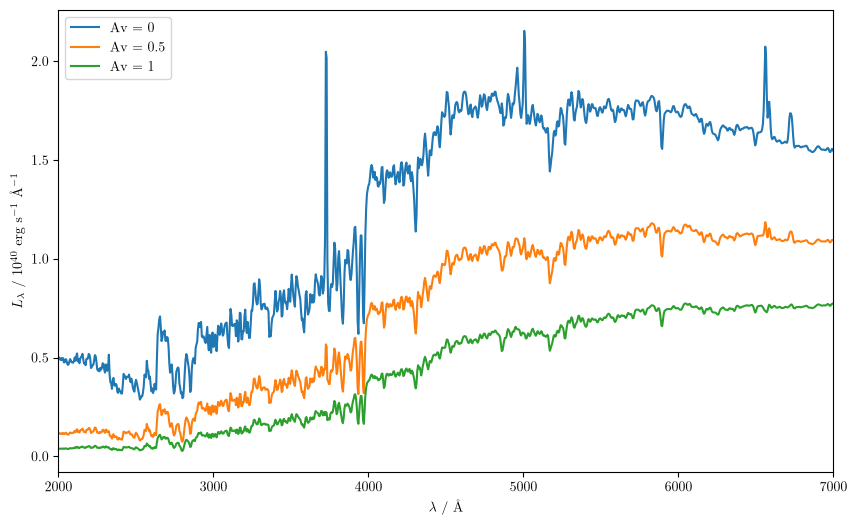

In [9]:
Dust_val = [0, 0.5, 1]
fig, ax = plt.subplots(figsize = (10, 6))
for av in Dust_val:
    new = copy.deepcopy(model_components)
    new['dust']['Av'] = av
    model = model_galaxy(new, filt_list=None, spec_wavs=wavelength_grid, spec_units='ergscma', phot_units='ergscma', index_list=None)
    wavelength = model.spectrum[:, 0]
    luminosity = model.spectrum[:, 1]
    ax.plot(wavelength, luminosity / 10**40, label = f"Av = {av}")
ax.legend()
ax.set_xlim(np.min(wavelength), np.max(wavelength))
ax.set_xlabel(r"$\lambda$ / \AA")
ax.set_ylabel(r"$L_\lambda\ /\ 10^{40}$ erg s$^{-1}$ \AA$^{-1}$")


## Experiment 1: How varying the V-band attenuation (Av) changes the galaxy's SED profile?

By increasing Av from 0 to 0.5 and 1, respectively, we can see that at 2000A the light is dimmed by a factor of 10. In comparison, at the far right end of the spectrum, the 7000A light is only dimmed by a factor of 3. Therefore, dust attenuation not only dims the galaxy's spectrum, it is particularly making the galaxy redder. 


### Why $A_V = 1$ dims 5500 Å light by a factor of 2.5

Attenuation is a difference in magnitudes:

$$A_\lambda = m_\text{with dust} - m_\text{without dust} = -2.5\log_{10}\left(\frac{F_\text{with dust}}{F_\text{without dust}}\right)$$

Solving for the flux ratio:

$$\frac{F_\text{with dust}}{F_\text{without dust}} = 10^{-0.4A_\lambda}$$

For $A_\lambda = 1$ this is $10^{-0.4} \approx 0.398$: about 40% of the light
gets through, a dimming factor of $10^{0.4} \approx 2.512$.

BAGPIPES writes $A_\lambda = A_V\,k(\lambda)$ with $k(5500\,\text{Å}) = 1$ (normalization choice),
so at 5500 Å, $A_\lambda = A_V$ for any dust law. At other wavelengths
$k(\lambda) \neq 1$, hence the factor of ~11 at 2000 Å and ~2 at 7000 Å.

**Link to optical depth.** Comparing with Beer–Lambert, $F = F_0 e^{-\tau}$:

$$A = \frac{2.5}{\ln 10}\,\tau \approx 1.086\,\tau$$

so $A_V = 1$ corresponds to $\tau_V \approx 0.92$.

In [13]:
uv_wavelength_grid = np.arange(1200, 7005, 5) # units A

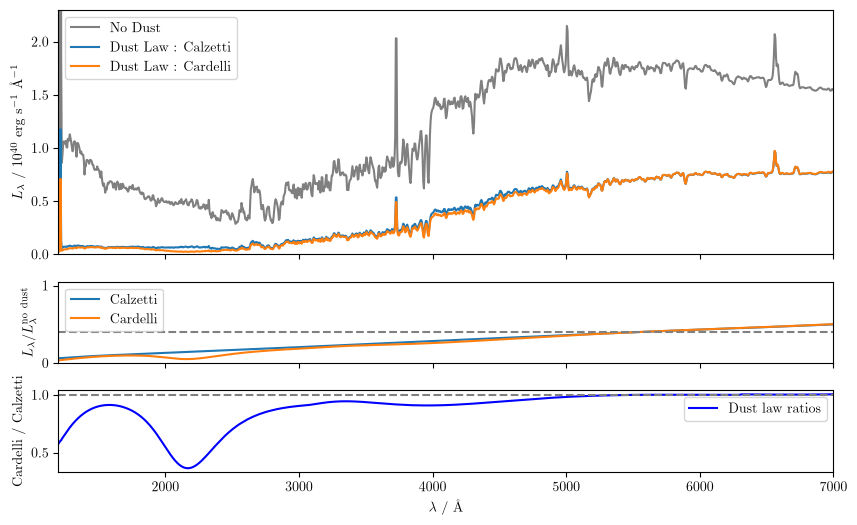

In [36]:
laws = ["Calzetti", "Cardelli"]
fig, (ax, ax1, ax2) = plt.subplots(ncols=1, nrows = 3, figsize = (10, 6), sharex=True, gridspec_kw={"height_ratios": [3, 1, 1]})

nodust = copy.deepcopy(model_components)
nodust['dust']['Av'] = 0
model_nodust = model_galaxy(nodust, filt_list=None, spec_wavs=uv_wavelength_grid, spec_units='ergscma', phot_units='ergscma', index_list=None)


spectra = {}
spectra['nodust'] = model_nodust.spectrum[:, 1]
ax.plot(uv_wavelength_grid, spectra['nodust'] / 10**40, label = "No Dust", color = 'grey')
for law in laws:
    new = copy.deepcopy(model_components)
    new['dust']['type'] = law
    new['dust']['Av'] = 1
    new['dust']['eta'] = 1
    m = model_galaxy(new, filt_list=None, spec_wavs=uv_wavelength_grid, spec_units='ergscma', phot_units='ergscma', index_list=None)
    spectra[law] = m.spectrum[:, 1]
    ax.plot(uv_wavelength_grid, spectra[law] / 10**40, label = f"Dust Law : {law}")
    ax1.plot(uv_wavelength_grid, spectra[law] / spectra['nodust'], label = f"{law}")
ax.legend()
ax.set_xlim(np.min(wavelength), np.max(wavelength))
ax.set_ylim(0, 2.3)
ax.set_ylabel(r"$L_\lambda\ /\ 10^{40}$ erg s$^{-1}$ \AA$^{-1}$")

ax1.set_ylim(0, 1.05)
ax1.set_ylabel(r"$L_\lambda / L_\lambda^\mathrm{no\ dust}$")
ax1.axhline(10**-0.4, color="grey", linestyle="--")
ax1.legend()

ax2.plot(uv_wavelength_grid, spectra["Cardelli"]/spectra["Calzetti"], label = "Dust law ratios", color = 'b')
ax2.set_ylabel("Cardelli / Calzetti")
ax2.axhline(1, color="grey", linestyle="--")
ax2.set_xlabel(r"$\lambda$ / \AA")
ax2.legend()